# Logistic Regression for Anomaly Detection

This notebook implements Logistic Regression to identify anomalous users in a recommender system dataset.

### Pipeline Overview
1. Load and inspect data
2. Build per-user feature vectors (pivot to user × item rating matrix)
3. Reduce dimensionality with TruncatedSVD (handles sparsity well)
4. Train Logistic Regression with class balancing
5. Evaluate with AUC, Precision, Recall, F1
6. Generate and save anomaly scores for submission

## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, classification_report
)

# Load training data
data = np.load("training_batch_with_labels.npz")
X_raw = data["X"]   # shape: (n_interactions, 3) — [user_id, item_id, rating]
y_raw = data["y"]   # shape: (n_users, 2)  — [user_id, label]

print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")

Interactions : 177,346
Users        : 1100
Items        : 993
Anomalous    : 100
Normal       : 1000


## 2. Feature Engineering — Per-User Vectors

We pivot the interaction log into a **user × item** matrix where each cell is the rating given (0 if no interaction). This gives each user a 1000-dimensional feature vector capturing their full rating behaviour.

In [2]:
# ── Build per-user feature matrix ──────────────────────────────────────────

interactions = pd.DataFrame(X_raw, columns=["user", "item", "rating"])
labels_df    = pd.DataFrame(y_raw, columns=["user", "label"])

# Pivot: rows = users, columns = items, values = rating (NaN → 0)
user_item = interactions.pivot_table(
    index="user", columns="item", values="rating", aggfunc="mean"
).fillna(0) # fill NA values with 0

# Align labels to the same user order
labels_df = labels_df.set_index("user").loc[user_item.index].reset_index()
y = labels_df["label"].values

print(f"User-item matrix shape : {user_item.shape}")
print(f"Label array shape      : {y.shape}")
print(f"Class balance          : {np.bincount(y)}  (normal, anomaly)")

# ── Additional handcrafted features ────────────────────────────────────────
# These capture high-level behavioural signals that anomalies may exhibit

agg = interactions.groupby("user").agg(
    num_ratings    = ("rating", "count"),
    mean_rating    = ("rating", "mean"),
    std_rating     = ("rating", "std"),
    num_items      = ("item",   "nunique"),
    pct_extreme    = ("rating", lambda r: ((r == 0) | (r == 5)).mean()),  # fraction of 0/5 ratings
    pct_zero       = ("rating", lambda r: (r == 0).mean()),
    pct_five       = ("rating", lambda r: (r == 5).mean()),
).fillna(0)

# Reindex to match user_item order
agg = agg.loc[user_item.index]

print("\nHandcrafted features:")
print(agg.head())

User-item matrix shape : (1100, 993)
Label array shape      : (1100,)
Class balance          : [1000  100]  (normal, anomaly)

Handcrafted features:
      num_ratings  mean_rating  std_rating  num_items  pct_extreme  pct_zero  \
user                                                                           
100            88     3.147727    1.169928         88     0.113636  0.045455   
101           231     3.406926    0.854016        231     0.095238  0.008658   
102            98     3.673469    1.072385         98     0.193878  0.000000   
103           103     3.000000    1.290994        103     0.126214  0.058252   
104            89     3.719101    0.988442         89     0.235955  0.000000   

      pct_five  
user            
100   0.068182  
101   0.086580  
102   0.193878  
103   0.067961  
104   0.235955  


## 3. Dimensionality Reduction

The raw user-item matrix has up to 1000 columns. We use **TruncatedSVD** (a sparse-friendly PCA) to compress it into a lower-dimensional embedding, then concatenate the handcrafted features.

In [22]:
N_COMPONENTS = 50 # latent dimensions from SVD — tune this if needed

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_item_svd = svd.fit_transform(user_item.values)

explained = svd.explained_variance_ratio_.sum()
print(f"Variance explained by {N_COMPONENTS} components: {explained:.1%}")

# Combine SVD embedding + handcrafted features
X_features = np.hstack([user_item_svd, agg.values])
print(f"Final feature matrix shape: {X_features.shape}")

Variance explained by 50 components: 54.5%
Final feature matrix shape: (1100, 57)


## 4. Logistic Regression Model

Key design choices:
- **`class_weight='balanced'`** — automatically up-weights the rare anomaly class (100 vs 1000 users), preventing the model from ignoring anomalies.
- **StandardScaler** — logistic regression is sensitive to feature scale.
- **`solver='lbfgs'`** with L2 regularisation — stable for this size.
- **Stratified 5-fold CV** — preserves class ratio in each fold; gives reliable AUC estimates on an imbalanced dataset.

In [23]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(
                   class_weight="balanced",  # handles 10:1 imbalance
                   max_iter=1000,
                   solver="lbfgs",
                   C=0.01,                    # regularisation strength; tune via grid search
                   random_state=42
               ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Get out-of-fold anomaly probability scores
y_scores_cv = cross_val_predict(
    pipeline, X_features, y,
    cv=cv, method="predict_proba"
)[:, 1]   # probability of being anomalous

y_pred_cv = (y_scores_cv >= 0.5).astype(int)

print("=== Cross-validated Performance ===")
print(f"AUC       : {roc_auc_score(y, y_scores_cv):.4f}")
print(f"Precision : {precision_score(y, y_pred_cv):.4f}")
print(f"Recall    : {recall_score(y, y_pred_cv):.4f}")
print(f"F1        : {f1_score(y, y_pred_cv):.4f}")
print()
print(classification_report(y, y_pred_cv, target_names=["Normal", "Anomaly"]))

=== Cross-validated Performance ===
AUC       : 0.8391
Precision : 0.3143
Recall    : 0.6600
F1        : 0.4258

              precision    recall  f1-score   support

      Normal       0.96      0.86      0.91      1000
     Anomaly       0.31      0.66      0.43       100

    accuracy                           0.84      1100
   macro avg       0.64      0.76      0.67      1100
weighted avg       0.90      0.84      0.86      1100



## 5. ROC Curve

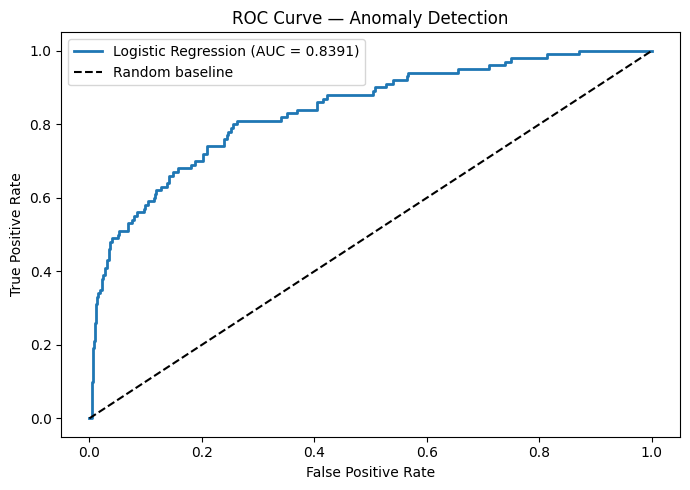

In [24]:
fpr, tpr, thresholds = roc_curve(y, y_scores_cv)
auc = roc_auc_score(y, y_scores_cv)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.show()

## Precision-Recall Curve

C:\Users\xavie\AppData\Local\Temp\ipykernel_30072\4147591953.py:38: RuntimeWarning: invalid value encountered in divide
  2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),


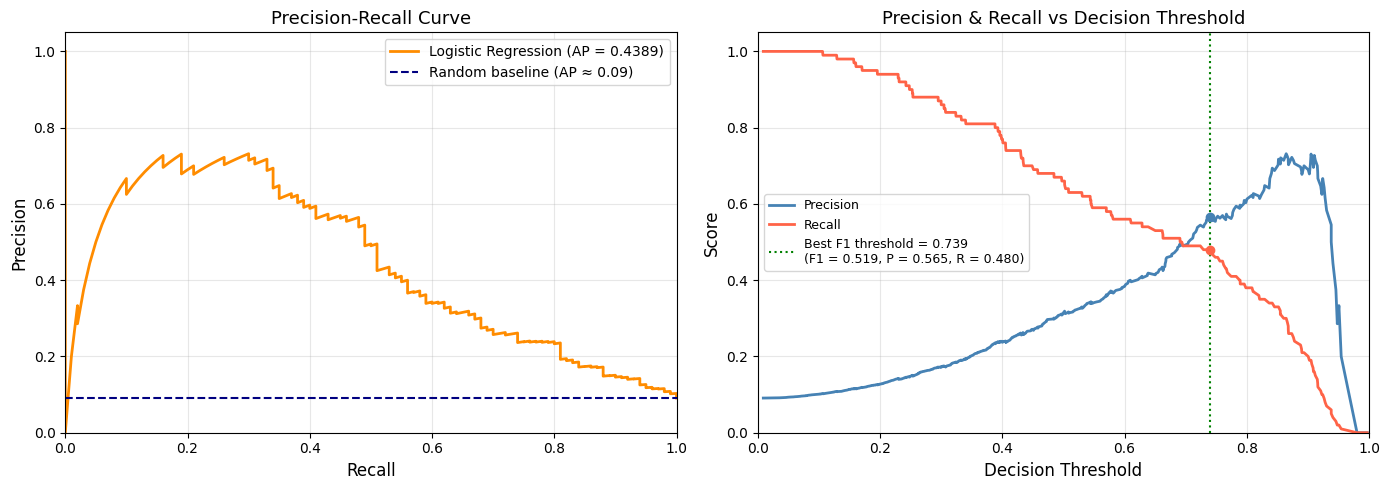

Average Precision (AP)  : 0.4389
Random baseline AP      : 0.0909  (= anomaly prevalence)
Improvement over random : 4.8x

Best F1 threshold : 0.739
  Precision       : 0.5647
  Recall          : 0.4800
  F1              : 0.5189


In [29]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay
)

# ── Compute PR curve from cross-validated scores ────────────────────────────
# y_scores_cv and y must already exist from the logistic regression notebook
precision_vals, recall_vals, thresholds = precision_recall_curve(y, y_scores_cv)
ap = average_precision_score(y, y_scores_cv)
baseline = y.mean()   # a random classifier sits at this precision level

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: full PR curve ---
ax = axes[0]
ax.plot(recall_vals, precision_vals, lw=2, color="darkorange",
        label=f"Logistic Regression (AP = {ap:.4f})")
ax.axhline(baseline, color="navy", linestyle="--",
           label=f"Random baseline (AP ≈ {baseline:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Right: Precision & Recall vs Threshold ---
ax2 = axes[1]
ax2.plot(thresholds, precision_vals[:-1], lw=2, color="steelblue",  label="Precision")
ax2.plot(thresholds, recall_vals[:-1],    lw=2, color="tomato",     label="Recall")

# Mark F1-optimal threshold
f1_scores = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

ax2.axvline(best_thresh, color="green", linestyle=":", lw=1.5,
            label=f"Best F1 threshold = {best_thresh:.3f}\n(F1 = {best_f1:.3f}, "
                  f"P = {precision_vals[best_idx]:.3f}, R = {recall_vals[best_idx]:.3f})")
ax2.scatter([best_thresh], [precision_vals[best_idx]], color="steelblue", zorder=5)
ax2.scatter([best_thresh], [recall_vals[best_idx]],    color="tomato",    zorder=5)

ax2.set_xlabel("Decision Threshold", fontsize=12)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Precision & Recall vs Decision Threshold", fontsize=13)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Precision (AP)  : {ap:.4f}")
print(f"Random baseline AP      : {baseline:.4f}  (= anomaly prevalence)")
print(f"Improvement over random : {ap / baseline:.1f}x")
print()
print(f"Best F1 threshold : {best_thresh:.3f}")
print(f"  Precision       : {precision_vals[best_idx]:.4f}")
print(f"  Recall          : {recall_vals[best_idx]:.4f}")
print(f"  F1              : {best_f1:.4f}")

In [30]:
# ── Sample the curve at fixed recall levels ─────────────────────────────────
sample_recalls = np.linspace(0, 1, 11)   # 0.0, 0.1, ..., 1.0

rows = []
for target_r in sample_recalls:
    # Find index where recall is closest to the target
    idx = np.argmin(np.abs(recall_vals - target_r))
    thresh = thresholds[idx] if idx < len(thresholds) else 1.0
    rows.append({
        "Recall (target)" : f"{target_r:.1f}",
        "Recall (actual)" : f"{recall_vals[idx]:.4f}",
        "Precision"       : f"{precision_vals[idx]:.4f}",
        "Threshold"       : f"{thresh:.4f}",
    })

pr_table = pd.DataFrame(rows)
print(pr_table.to_string(index=False))

Recall (target) Recall (actual) Precision Threshold
            0.0          0.0000    0.0000    0.9804
            0.1          0.1000    0.6250    0.9229
            0.2          0.2000    0.6897    0.9005
            0.3          0.3000    0.7143    0.8604
            0.4          0.4000    0.5882    0.7884
            0.5          0.5000    0.4902    0.6910
            0.6          0.6000    0.3390    0.5451
            0.7          0.7000    0.2574    0.4352
            0.8          0.8000    0.2332    0.3884
            0.9          0.9000    0.1459    0.2482
            1.0          1.0000    0.0909    0.0090


In [ ]:
# ── Export Performance Results to Excel (append mode) ────────────────────────
import os, openpyxl
from datetime import datetime
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, classification_report
)

EXCEL_PATH = 'performance_results.xlsx'

# ── Helper styles ────────────────────────────────────────────────────────────
HEADER_FILL  = PatternFill('solid', start_color='1F4E79', end_color='1F4E79')
SECTION_FILL = PatternFill('solid', start_color='BDD7EE', end_color='BDD7EE')
ALT_FILL     = PatternFill('solid', start_color='DEEAF1', end_color='DEEAF1')
RUN_FILL     = PatternFill('solid', start_color='E2EFDA', end_color='E2EFDA')
HEADER_FONT  = Font(name='Arial', bold=True, color='FFFFFF', size=11)
SECTION_FONT = Font(name='Arial', bold=True, color='1F4E79', size=10)
RUN_FONT     = Font(name='Arial', bold=True, color='375623', size=10)
BODY_FONT    = Font(name='Arial', size=10)
CENTER = Alignment(horizontal='center', vertical='center')
LEFT   = Alignment(horizontal='left',   vertical='center')
thin   = Side(style='thin', color='9DC3E6')
BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_header(cell, text):
    cell.value = text; cell.font = HEADER_FONT; cell.fill = HEADER_FILL
    cell.alignment = CENTER; cell.border = BORDER

def style_section(cell, text):
    cell.value = text; cell.font = SECTION_FONT; cell.fill = SECTION_FILL
    cell.alignment = LEFT; cell.border = BORDER

def style_body(cell, value, alt=False, num_fmt='0.0000'):
    cell.value = value; cell.font = BODY_FONT
    cell.fill = ALT_FILL if alt else PatternFill(fill_type=None)
    cell.alignment = CENTER; cell.border = BORDER
    if isinstance(value, float): cell.number_format = num_fmt

def style_run_header(cell, text):
    cell.value = text; cell.font = RUN_FONT; cell.fill = RUN_FILL
    cell.alignment = LEFT; cell.border = BORDER

def set_col_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

def next_empty_row(ws):
    """Return the first fully-empty row index (1-based) in a worksheet."""
    return ws.max_row + 2  # leave one blank separator row

# ── Determine run number & timestamp ─────────────────────────────────────────
run_ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# ── Load or create workbook ───────────────────────────────────────────────────
if os.path.exists(EXCEL_PATH):
    wb = openpyxl.load_workbook(EXCEL_PATH)
else:
    wb = openpyxl.Workbook()
    wb.remove(wb.active)  # remove default blank sheet

# Derive run number from how many CV-Performance sheets already exist
existing_cv = [s for s in wb.sheetnames if s.startswith('CV Performance')]
run_num = len(existing_cv) + 1
run_label = f'Run {run_num}'
run_header_text = f'{run_label}  |  {run_ts}  |  C={pipeline.named_steps["lr"].C}  |  SVD components={N_COMPONENTS}'

# ── Recompute all metrics ─────────────────────────────────────────────────────
auc_val   = roc_auc_score(y, y_scores_cv)
prec_val  = precision_score(y, y_pred_cv)
rec_val   = recall_score(y, y_pred_cv)
f1_val    = f1_score(y, y_pred_cv)
report    = classification_report(y, y_pred_cv,
                target_names=['Normal', 'Anomaly'], output_dict=True)

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_scores_cv)
ap       = average_precision_score(y, y_scores_cv)
baseline = float(y.mean())
f1_scores_pr = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_pr_idx  = int(np.argmax(f1_scores_pr))
best_thresh  = float(pr_thresholds[best_pr_idx])
best_f1_pr   = float(f1_scores_pr[best_pr_idx])

# ════════════════════════════════════════════════════════════════════════════
# SHEET 1 — Cross-Validation Performance  (one sheet per run)
# ════════════════════════════════════════════════════════════════════════════
sheet_name_cv = f'CV Performance'
if sheet_name_cv in wb.sheetnames:
    ws1 = wb[sheet_name_cv]
    r = next_empty_row(ws1)
else:
    ws1 = wb.create_sheet(sheet_name_cv)
    r = 1
    # Write column headers only once
    style_header(ws1['A1'], 'Run')
    style_header(ws1['B1'], 'Timestamp')
    style_header(ws1['C1'], 'C (regularisation)')
    style_header(ws1['D1'], 'SVD Components')
    style_header(ws1['E1'], 'AUC')
    style_header(ws1['F1'], 'Precision')
    style_header(ws1['G1'], 'Recall')
    style_header(ws1['H1'], 'F1')
    style_header(ws1['I1'], 'AP (PR curve)')
    style_header(ws1['J1'], 'Best-F1 Threshold')
    style_header(ws1['K1'], 'Best-F1 Score')
    set_col_widths(ws1, [8, 20, 20, 16, 10, 12, 10, 10, 14, 18, 14])
    r = 2

alt = (run_num % 2 == 0)
for col, val, fmt in [
    (1,  run_num,                                          '0'),
    (2,  run_ts,                                           '@'),
    (3,  float(pipeline.named_steps['lr'].C),              '0.####'),
    (4,  N_COMPONENTS,                                     '0'),
    (5,  auc_val,                                          '0.0000'),
    (6,  prec_val,                                         '0.0000'),
    (7,  rec_val,                                          '0.0000'),
    (8,  f1_val,                                           '0.0000'),
    (9,  ap,                                               '0.0000'),
    (10, best_thresh,                                      '0.0000'),
    (11, best_f1_pr,                                       '0.0000'),
]:
    style_body(ws1.cell(r, col), val, alt, num_fmt=fmt)

# ════════════════════════════════════════════════════════════════════════════
# SHEET 2 — ROC Curve  (append a new block per run)
# ════════════════════════════════════════════════════════════════════════════
if 'ROC Curve' in wb.sheetnames:
    ws2 = wb['ROC Curve']
    r2 = next_empty_row(ws2)
else:
    ws2 = wb.create_sheet('ROC Curve')
    r2 = 1
    set_col_widths(ws2, [22, 22, 18, 28])

# Run header
ws2.merge_cells(f'A{r2}:D{r2}')
style_run_header(ws2.cell(r2, 1), run_header_text)
ws2.row_dimensions[r2].height = 18

# Column headers
style_header(ws2.cell(r2+1, 1), 'False Positive Rate')
style_header(ws2.cell(r2+1, 2), 'True Positive Rate')
style_header(ws2.cell(r2+1, 3), 'Threshold')
style_header(ws2.cell(r2+1, 4), 'Notes')

n_points = min(len(fpr), 100)
idx = np.round(np.linspace(0, len(fpr) - 1, n_points)).astype(int)
fpr_s    = fpr[idx]
tpr_s    = tpr[idx]
thresh_s = np.append(thresholds, np.nan)[idx]

for offset, (fp, tp, th) in enumerate(zip(fpr_s, tpr_s, thresh_s)):
    row_i = r2 + 2 + offset
    alt   = (offset % 2 == 1)
    style_body(ws2.cell(row_i, 1), float(fp), alt)
    style_body(ws2.cell(row_i, 2), float(tp), alt)
    style_body(ws2.cell(row_i, 3), None if np.isnan(th) else float(th), alt)
    style_body(ws2.cell(row_i, 4),
               f'AUC = {auc_val:.4f} — first point (no threshold)' if offset == 0 else '',
               alt, num_fmt='@')

# ════════════════════════════════════════════════════════════════════════════
# SHEET 3 — Precision-Recall Curve  (append a new block per run)
# ════════════════════════════════════════════════════════════════════════════
if 'Precision-Recall Curve' in wb.sheetnames:
    ws3 = wb['Precision-Recall Curve']
    r3 = next_empty_row(ws3)
else:
    ws3 = wb.create_sheet('Precision-Recall Curve')
    r3 = 1
    set_col_widths(ws3, [20, 18, 16, 16])

# Run header
ws3.merge_cells(f'A{r3}:D{r3}')
style_run_header(ws3.cell(r3, 1), run_header_text)
ws3.row_dimensions[r3].height = 18

# Summary
ws3.merge_cells(f'A{r3+1}:D{r3+1}')
c2 = ws3.cell(r3+1, 1)
c2.value = (
    f'AP = {ap:.4f}  |  Random baseline ≈ {baseline:.4f}  |  '
    f'Improvement {ap/baseline:.1f}x  |  '
    f'Best-F1 threshold = {best_thresh:.3f}  '
    f'(F1={best_f1_pr:.4f}, P={precision_vals[best_pr_idx]:.4f}, R={recall_vals[best_pr_idx]:.4f})'
)
c2.font = Font(name='Arial', size=9)
c2.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)
ws3.row_dimensions[r3+1].height = 26

# Section A: Sampled PR table
ws3.merge_cells(f'A{r3+2}:D{r3+2}')
style_section(ws3.cell(r3+2, 1), 'Sampled PR Table (fixed recall levels 0.0 – 1.0)')
style_header(ws3.cell(r3+3, 1), 'Recall (target)')
style_header(ws3.cell(r3+3, 2), 'Recall (actual)')
style_header(ws3.cell(r3+3, 3), 'Precision')
style_header(ws3.cell(r3+3, 4), 'Threshold')

for s_off, target_r in enumerate(np.linspace(0, 1, 11)):
    idx2 = int(np.argmin(np.abs(recall_vals - target_r)))
    th2  = float(pr_thresholds[idx2]) if idx2 < len(pr_thresholds) else 1.0
    alt  = (s_off % 2 == 1)
    row_i = r3 + 4 + s_off
    style_body(ws3.cell(row_i, 1), float(target_r), alt)
    style_body(ws3.cell(row_i, 2), float(recall_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 3), float(precision_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 4), th2, alt)

# Section B: Full PR curve (downsampled)
sec_b_start = r3 + 16
ws3.merge_cells(f'A{sec_b_start}:D{sec_b_start}')
style_section(ws3.cell(sec_b_start, 1), 'Full PR Curve (downsampled to 100 points)')
style_header(ws3.cell(sec_b_start+1, 1), 'Recall')
style_header(ws3.cell(sec_b_start+1, 2), 'Precision')
style_header(ws3.cell(sec_b_start+1, 3), 'Threshold')
style_header(ws3.cell(sec_b_start+1, 4), 'F1 Score')

n_pts  = min(len(precision_vals)-1, 100)
pr_idx = np.round(np.linspace(0, len(precision_vals)-2, n_pts)).astype(int)

for p_off, pi in enumerate(pr_idx):
    row_i = sec_b_start + 2 + p_off
    alt   = (p_off % 2 == 1)
    f1v   = (2*precision_vals[pi]*recall_vals[pi]/(precision_vals[pi]+recall_vals[pi])
             if (precision_vals[pi]+recall_vals[pi]) > 0 else 0.0)
    style_body(ws3.cell(row_i, 1), float(recall_vals[pi]), alt)
    style_body(ws3.cell(row_i, 2), float(precision_vals[pi]), alt)
    style_body(ws3.cell(row_i, 3), float(pr_thresholds[pi]), alt)
    style_body(ws3.cell(row_i, 4), float(f1v), alt)

# ── Save ─────────────────────────────────────────────────────────────────────
wb.save(EXCEL_PATH)
print(f'{EXCEL_PATH} updated — {run_label} appended ({run_ts})')


## 6. Anomaly Score Distribution

A well-trained model should separate the score distributions of normal vs anomalous users.

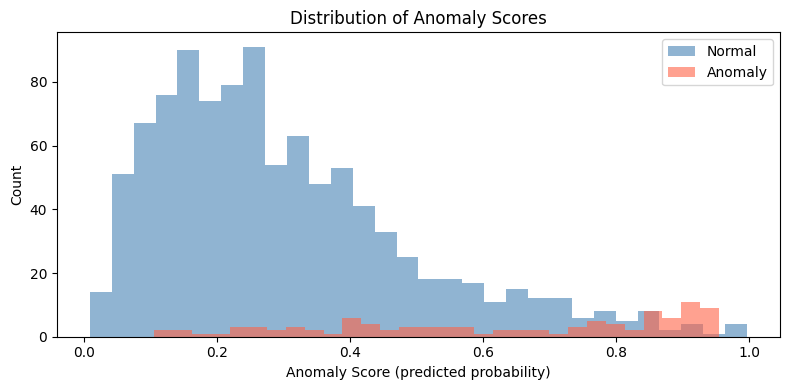

In [25]:
plt.figure(figsize=(8, 4))
plt.hist(y_scores_cv[y == 0], bins=30, alpha=0.6, label="Normal",   color="steelblue")
plt.hist(y_scores_cv[y == 1], bins=30, alpha=0.6, label="Anomaly",  color="tomato")
plt.xlabel("Anomaly Score (predicted probability)")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train Final Model & Generate Submission

We refit on the full training set, then score the held-out test batch.

In [26]:
# ── Fit on ALL training data ────────────────────────────────────────────────
pipeline.fit(X_features, y)
print("Final model trained on full training set.")

Final model trained on full training set.


In [27]:
# ── Helper: build features for any interaction batch ────────────────────────
def build_features(X_interactions, svd_model, agg_columns, all_items):
    """
    Given a raw interaction array (user, item, rating), return the same
    feature matrix used during training.
    
    Parameters
    ----------
    X_interactions : np.ndarray, shape (n, 3)
    svd_model      : fitted TruncatedSVD
    agg_columns    : list of column names for the handcrafted features
    all_items      : the full item index from training (ensures consistent columns)
    """
    df = pd.DataFrame(X_interactions, columns=["user", "item", "rating"])
    users = sorted(df["user"].unique())

    pivot = df.pivot_table(
        index="user", columns="item", values="rating", aggfunc="mean"
    ).reindex(columns=all_items, fill_value=0).fillna(0)

    svd_feats = svd_model.transform(pivot.values)

    agg_new = df.groupby("user").agg(
        num_ratings = ("rating", "count"),
        mean_rating = ("rating", "mean"),
        std_rating  = ("rating", "std"),
        num_items   = ("item",   "nunique"),
        pct_extreme = ("rating", lambda r: ((r == 0) | (r == 5)).mean()),
        pct_zero    = ("rating", lambda r: (r == 0).mean()),
        pct_five    = ("rating", lambda r: (r == 5).mean()),
    ).fillna(0).loc[pivot.index]

    return np.hstack([svd_feats, agg_new.values]), pivot.index.tolist()


# ── Score the test batch ─────────────────────────────────────────────────────
data_test   = np.load("subset_training_batch.npz")
X_test_raw  = data_test["X"]

all_items = user_item.columns.tolist()   # item index from training

X_test_feats, test_users = build_features(
    X_test_raw, svd, agg.columns.tolist(), all_items
)

anomaly_scores = pipeline.predict_proba(X_test_feats)[:, 1]

print(f"Scored {len(anomaly_scores)} users")
print(f"Score range  : [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"Mean score   : {anomaly_scores.mean():.4f}")

# ── Save submission ──────────────────────────────────────────────────────────
np.savez("submission_lr.npz", predictions=anomaly_scores)
print("\nsubmission_lr.npz saved!")

Scored 220 users
Score range  : [0.0269, 0.9963]
Mean score   : 0.3265

submission_lr.npz saved!


## 8. (Optional) Hyperparameter Tuning

Run this cell to search over regularisation strength `C` and SVD components. This can meaningfully improve AUC.

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "lr__C": [0.01, 0.1, 1.0, 10.0, 100.0],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_features, y)

print(f"Best C   : {grid_search.best_params_['lr__C']}")
print(f"Best AUC : {grid_search.best_score_:.4f}")

# Results table
results = pd.DataFrame(grid_search.cv_results_)
print(results[["param_lr__C", "mean_test_score", "std_test_score"]].sort_values(
    "mean_test_score", ascending=False
))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C   : 0.01
Best AUC : 0.8384
   param_lr__C  mean_test_score  std_test_score
0         0.01          0.83845        0.023183
1         0.10          0.82175        0.017459
2         1.00          0.81205        0.016144
3        10.00          0.81110        0.016167
4       100.00          0.81100        0.016017
